In [1]:
!git clone https://github.com/kuiper2000/seasonal_tornado_forecast_demo.git
!pip install descartes
!pip install netCDF4
!pip install cartopy
# import cartopy

Cloning into 'seasonal_tornado_forecast_demo'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 28.22 MiB | 22.92 MiB/s, done.


## Preparing User Defined DATA (can you for specific task)

In [5]:
import numpy as np
import sys
import importlib

# Add the directory containing Tornado_github.py to sys.path
sys.path.insert(0, '/content/seasonal_tornado_forecast_demo/')

# Force reload to pick up any fixes in Tornado_github.py
if 'Tornado_github' in sys.modules:
    importlib.reload(sys.modules['Tornado_github']) # Reload by module name, not path
from Tornado_github import tornado_git

# data_sst     = np.load('SST_EOFs_1995_2017_based.npz')
# data_tornado = np.load('github_demo.npz')
data_sst     = np.load('/content/seasonal_tornado_forecast_demo/SST_EOFs_1995_2017_based.npz')
data_tornado = np.load('/content/seasonal_tornado_forecast_demo/github_demo.npz')

#20 SST PCs, 15 ensemble, 12 initialization months, 30 years (1992-2022), 12 month of forecast lead time
#20 SST EOFs, number lat, number of longitude  
print("=== SST keys ===")
for key in data_sst.files:
    print(f"  {key}: shape={data_sst[key].shape}, dtype={data_sst[key].dtype}")


print("\n=== Tornado keys ===")
for key in data_tornado.files:
    print(f"  {key}: shape={data_tornado[key].shape}, dtype={data_tornado[key].dtype}")
# CONUS tornado (number of reports) from 1992-2022, lat, lon (see next two variables)


pcs_obs_sst = data_sst['pcs_obs_sst'].mean(axis=1)
EOFs        = data_sst['EOF']
tornado     = data_tornado['tornado_month']

# Load all lat/lon arrays — we'll pick the right ones for the 1403 grid points
tornado_lat_full = data_tornado['lat']
tornado_lon_full = data_tornado['lon']

print(f"\ntornado shape     : {tornado.shape}")
print(f"lat/lon shape     : {tornado_lat_full.shape} / {tornado_lon_full.shape}")

tornado_model = tornado_git(tornado_data=tornado,
                            predictor=np.reshape(pcs_obs_sst, [20, 12, 30*12]),
                            init_year=1992)
print("tornado_git instance created successfully.")


=== SST keys ===
  pcs_obs_sst: shape=(20, 15, 12, 30, 12), dtype=float64
  EOF: shape=(20, 360, 576), dtype=float64
  variance: shape=(20,), dtype=float64

=== Tornado keys ===
  tornado_month: shape=(30, 1403), dtype=float64
  lat: shape=(23, 61), dtype=float64
  lon: shape=(23, 61), dtype=float64

tornado shape     : (30, 1403)
lat/lon shape     : (23, 61) / (23, 61)
tornado_git instance created successfully.


In [ ]:
# # Leave-one-out Corss Validation
# # ── Run the forecast and retrieve predict & coef ──────────────────────────────
# predict, coef = tornado_model._forecast()

# # predict : (n_modes, 12, 12, n_years, n_tor_months)
# #            mode    init pred  year    target
# # coef    : (12, 12, n_years, n_modes, n_tor_months)
# print(f"predict shape : {predict.shape}")
# print(f"coef shape    : {coef.shape}")


working on mode = 1
working on mode = 2
working on mode = 3
working on mode = 4
working on mode = 5
working on mode = 6
working on mode = 7
working on mode = 8
working on mode = 9
working on mode = 10
working on mode = 11
working on mode = 12
working on mode = 13
working on mode = 14
working on mode = 15
working on mode = 16
working on mode = 17
working on mode = 18
working on mode = 19
working on mode = 20
predict shape : (20, 12, 12, 30, 1403)
coef shape    : (12, 12, 30, 20, 1403)


# Model Main Class (also check tornado git for detailed calculation)

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
import importlib
import Tornado_github
importlib.reload(Tornado_github)
from Tornado_github import tornado_git
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import pearsonr


def predict_conus_tornado(target_year,
                          pcs_obs_sst,
                          EOFs,
                          tornado,
                          tornado_lat_full,
                          tornado_lon_full,
                          init_month=12,
                          pred_month=12,
                          n_modes=20,
                          init_year=1992):
    """
    Predict CONUS tornado activity for a user-specified year.

    Parameters
    ----------
    target_year      : int    Year to forecast (must be within the data range).
    pcs_obs_sst      : ndarray  Ensemble-averaged observed SST principal components,
                                reshapeable to (n_modes, 12, n_years*12).
    EOFs             : ndarray  SST EOF spatial patterns (n_modes, n_lat, n_lon).
    tornado          : ndarray  Raw tornado count data passed to tornado_git.
    tornado_lat_full : ndarray  Latitude  grid — shape (n_lat, n_lon) or (n_grid,).
    tornado_lon_full : ndarray  Longitude grid — shape (n_lat, n_lon) or (n_grid,).
    init_month       : int (1–12)  Initialisation month          [default 12 = Dec].
    pred_month       : int (1–12)  SST predictor month           [default 12 = Dec].
    n_modes          : int         Number of SST modes in regression [default 20].
    init_year        : int         First year of the dataset     [default 1992].

    Returns
    -------
    dict with keys
        'conus_total_forecast' : float    Predicted total CONUS tornado count.
        'conus_total_observed' : float    Observed  total CONUS tornado count.
        'forecast_pct'         : ndarray  Per-grid forecast (ECDF percentile space).
        'observed_pct'         : ndarray  Per-grid observed percentile.
        'correlation'          : float    Spatial Pearson r (forecast vs observed).
    """
    months_label = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    # ── 1. Build predictor array (n_modes, 12, n_years*12) ───────────────────
    n_modes_sst = pcs_obs_sst.shape[0]
    predictor   = np.reshape(pcs_obs_sst, [n_modes_sst, 12, -1])
    n_years     = predictor.shape[2] // 12

    # ── 2. Validate target year ───────────────────────────────────────────────
    yr_min, yr_max = init_year, init_year + n_years - 1
    if not (yr_min <= target_year <= yr_max):
        raise ValueError(
            f"target_year {target_year} is out of data range [{yr_min}, {yr_max}]."
        )
    year_idx = target_year - init_year

    # ── 3. Create model & run leave-one-out cross-validation ─────────────────
    print("Building tornado_git model … ", end="", flush=True)
    tornado_model = tornado_git(tornado_data=tornado,
                                predictor=predictor,
                                init_year=init_year)
    print("done.")
    print("Running leave-one-out cross-validation (this may take a moment) …")
    _, coef = tornado_model._forecast()      # coef: (12, 12, n_years, n_modes, n_grid)
    print("Cross-validation done.\n")

    # ── 4. Retrieve reshaped tornado array (n_years, n_grid) ─────────────────
    tor_arr = tornado_model.tornado          # reshaped in-place by _forecast()
    tor_lat = tornado_lat_full.ravel()
    tor_lon = tornado_lon_full.ravel()
    n_grid  = tor_arr.shape[1]

    # ── 5. Build point-wise ECDF percentile (observation ground-truth) ────────
    tor_pct_raw = np.zeros_like(tor_arr, dtype=float)
    for i in range(n_grid):
        ecdf = ECDF(tor_arr[:, i])
        tor_pct_raw[:, i] = ecdf(tor_arr[:, i])
    tor_pct_min  = tor_pct_raw.min(axis=0)
    tornado_model.tornado_percentile_min = tor_pct_min   # needed by predict_new()
    obs_full = tor_pct_raw                               # original ECDF scale

    # ── 6. Build the SST PC vector for the chosen target year & months ────────
    dates_1M       = pd.date_range(
        f'{init_year}-{init_month:02d}', periods=n_years * 12, freq='1ME'
    )
    predictor_posi = np.where(dates_1M.month == pred_month)[0]
    sst_pcs_new    = tornado_model.predictor[:, init_month - 1,
                                               predictor_posi[year_idx]]

    # ── 7. Make the forecast ──────────────────────────────────────────────────
    forecast_pct, coef_used = tornado_model.predict_new(
        sst_pcs    = sst_pcs_new,
        init_month = init_month,
        pred_month = pred_month,
        coef       = coef,
        n_modes    = n_modes,
    )
    obs_yr   = obs_full[year_idx, :]
    r_val, _ = pearsonr(obs_yr, forecast_pct)

    # ── 8. Back-transform percentile → raw tornado count (ECDF inversion) ────
    #       np.percentile(historical_counts, pct*100) ≈ inverse-ECDF
    forecast_count = np.array([
        float(np.percentile(tor_arr[:, i], np.clip(forecast_pct[i], 0, 1) * 100))
        for i in range(n_grid)
    ])
    obs_count            = tor_arr[year_idx, :]
    conus_total_forecast = forecast_count.sum()
    conus_total_observed = obs_count.sum()

    # ── 9. Print summary ──────────────────────────────────────────────────────
    print(f"{'═'*57}")
    print(f"  Target year              : {target_year}")
    print(f"  Initialisation month     : {months_label[init_month-1]}")
    print(f"  SST predictor month      : {months_label[pred_month-1]}")
    print(f"  SST modes used           : {n_modes}")
    print(f"{'─'*57}")
    print(f"  CONUS tornado forecast   : {conus_total_forecast:>10,.0f}")
    print(f"  CONUS tornado observed   : {conus_total_observed:>10,.0f}")
    print(f"  Spatial correlation (r)  : {r_val:>10.3f}")
    print(f"{'═'*57}\n")

    # ── 10. Activity mask (suppress near-zero climatological grid points) ──────
    tor_mean   = tor_arr.mean(axis=0)
    act_thresh = np.percentile(tor_mean[tor_mean > 0], 25)
    active     = tor_mean >= act_thresh
    fore_anom  = forecast_pct[active] - 0.5
    obs_anom   = obs_yr[active]        - 0.5

    # ── 11. Plotting ──────────────────────────────────────────────────────────
    cmap   = plt.cm.RdBu_r
    absmax = 0.5
    norm   = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    proj   = ccrs.PlateCarree()
    extent = [-125, -65, 22, 52]

    fig = plt.figure(figsize=(18, 11))

    # ── Row 1: diagnostic panels ──────────────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.scatter(obs_yr, forecast_pct, s=4, alpha=0.35, color='steelblue')
    lims = [min(obs_yr.min(), forecast_pct.min()),
            max(obs_yr.max(), forecast_pct.max())]
    ax1.plot(lims, lims, 'r--', lw=1.5, label='1:1 line')
    ax1.set_xlabel('Observed percentile', fontsize=10)
    ax1.set_ylabel('Forecast percentile', fontsize=10)
    ax1.set_title(f'Forecast vs Observed  (r = {r_val:.3f})', fontsize=10)
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3, linestyle='--')

    sort_idx = np.argsort(obs_yr)
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(obs_yr[sort_idx],       'k-',  lw=1.2, label='Observed', alpha=0.85)
    ax2.plot(forecast_pct[sort_idx], 'r--', lw=1.2, label='Forecast', alpha=0.85)
    ax2.set_xlabel('Grid point (sorted by observed)', fontsize=10)
    ax2.set_ylabel('Tornado percentile', fontsize=10)
    ax2.set_title('Grid-point comparison', fontsize=10)
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3, linestyle='--')

    ax3 = fig.add_subplot(2, 3, 3)
    mode_imp = np.abs(coef_used).mean(axis=1)
    bar_cols = plt.cm.YlOrRd(mode_imp / mode_imp.max())
    ax3.bar(range(1, len(mode_imp)+1), mode_imp,
            color=bar_cols, edgecolor='k', linewidth=0.5)
    dom = int(np.argmax(mode_imp)) + 1
    ax3.bar(dom, mode_imp[dom-1], color='crimson', edgecolor='k',
            linewidth=0.5, label=f'Dominant: M{dom}')
    ax3.set_xlabel('SST Mode', fontsize=10)
    ax3.set_ylabel('Mean |coefficient|', fontsize=10)
    ax3.set_title('SST mode importance', fontsize=10)
    ax3.grid(axis='y', alpha=0.3, linestyle='--'); ax3.legend(fontsize=8)

    # ── Row 2: spatial maps ───────────────────────────────────────────────────
    ax4 = fig.add_subplot(2, 3, 4, projection=proj)
    ax5 = fig.add_subplot(2, 3, 5, projection=proj)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for ax, title, anom in zip(
            [ax4, ax5],
            [f'Forecast anomaly  (year {target_year})',
             f'Observed anomaly  (year {target_year})'],
            [fore_anom, obs_anom]
        ):
            ax.set_extent(extent, crs=proj)
            ax.add_feature(cfeature.LAND,      facecolor='lightgrey', zorder=0)
            ax.add_feature(cfeature.OCEAN,     facecolor='aliceblue', zorder=0)
            ax.add_feature(cfeature.LAKES,     facecolor='aliceblue', zorder=0)
            ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='white',   zorder=1)
            ax.add_feature(cfeature.BORDERS,   linewidth=0.7, edgecolor='grey',    zorder=1)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimgrey', zorder=2)
            ax.scatter(tor_lon[active], tor_lat[active], c=anom,
                       cmap=cmap, norm=norm, s=28, marker='s',
                       transform=proj, zorder=3, linewidths=0)
            gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                              color='grey', alpha=0.4, linestyle='--')
            gl.top_labels = False; gl.right_labels = False
            gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
            ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    # Shared colourbar for the two maps
    cbar_ax = fig.add_axes([0.635, 0.07, 0.013, 0.36])
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
    cb.set_label('Tornado percentile anomaly\n(relative to 0.5 climatology)', fontsize=9)
    cb.set_ticks([-0.5, -0.25, 0, 0.25, 0.5])
    cb.ax.tick_params(labelsize=8)
    cb.ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

    # ── Row 2, right panel: CONUS total in historical context ─────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    all_years      = np.arange(init_year, init_year + n_years)
    obs_counts_all = tor_arr.sum(axis=1)
    clim_mean      = obs_counts_all.mean()

    ax6.bar(all_years, obs_counts_all, color='steelblue', alpha=0.45,
            label='Observed (all years)', zorder=2)
    ax6.bar(target_year, conus_total_observed, color='navy',    alpha=0.9,
            label=f'Observed {target_year}', zorder=3)
    ax6.bar(target_year, conus_total_forecast, color='crimson', alpha=0.80,
            width=0.45, label=f'Forecast {target_year}', zorder=4)
    ax6.axhline(clim_mean, color='k', lw=1.3, linestyle='--', label='Climatology')
    ax6.set_xlabel('Year', fontsize=10)
    ax6.set_ylabel('CONUS tornado count', fontsize=10)
    ax6.set_title(
        f'CONUS Total Tornado Count\n'
        f'Fcst = {conus_total_forecast:,.0f}  |  Obs = {conus_total_observed:,.0f}',
        fontsize=10
    )
    ax6.legend(fontsize=7, ncol=2)
    ax6.grid(axis='y', alpha=0.3, linestyle='--')
    ax6.set_xlim(init_year - 1, init_year + n_years)
    ax6.tick_params(axis='x', rotation=45, labelsize=8)

    plt.suptitle(
        f'CONUS Tornado Forecast — Year {target_year}  '
        f'(init = {months_label[init_month-1]},  pred = {months_label[pred_month-1]})\n'
        f'CONUS total  ▸  Forecast = {conus_total_forecast:,.0f}  |  '
        f'Observed = {conus_total_observed:,.0f}  |  Spatial r = {r_val:.3f}',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    out_fname = f'tornado_forecast_{target_year}.png'
    plt.savefig(out_fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {out_fname}")

    return {
        'conus_total_forecast': conus_total_forecast,
        'conus_total_observed': conus_total_observed,
        'forecast_pct':         forecast_pct,
        'observed_pct':         obs_yr,
        'correlation':          r_val,
    }


print("predict_conus_tornado() is ready.")


predict_conus_tornado() is ready.


# Run Model

Building tornado_git model … done.
Running leave-one-out cross-validation (this may take a moment) …
working on mode = 1
working on mode = 2
working on mode = 3
working on mode = 4
working on mode = 5
working on mode = 6
working on mode = 7
working on mode = 8
working on mode = 9
working on mode = 10
working on mode = 11
working on mode = 12
working on mode = 13
working on mode = 14
working on mode = 15
working on mode = 16
working on mode = 17
working on mode = 18
working on mode = 19
working on mode = 20
Cross-validation done.

═════════════════════════════════════════════════════════
  Target year              : 1993
  Initialisation month     : Dec
  SST predictor month      : Dec
  SST modes used           : 8
─────────────────────────────────────────────────────────
  CONUS tornado forecast   :         75
  CONUS tornado observed   :        153
  Spatial correlation (r)  :      0.898
═════════════════════════════════════════════════════════



/var/folders/x1/nb2x5h5j08b2xx8xkc64r43m0000gn/T/ipykernel_82147/1879830154.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/py

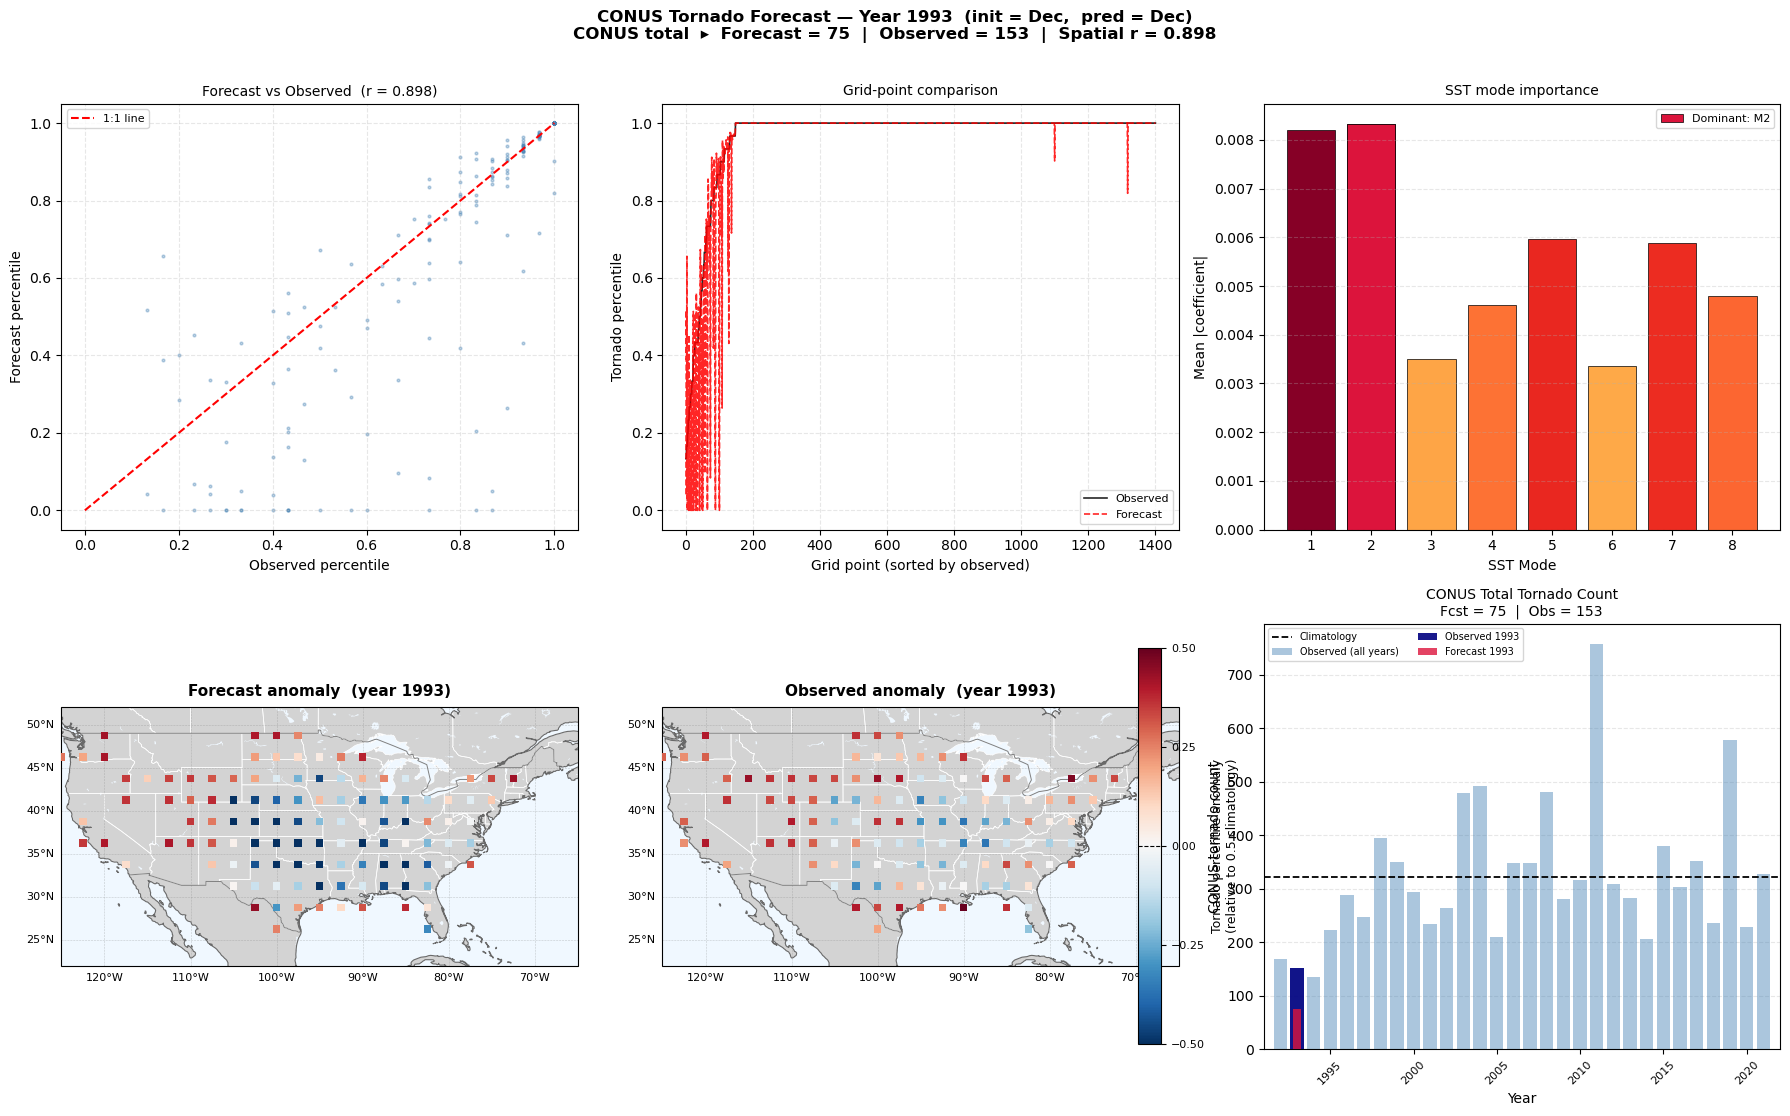

Figure saved → tornado_forecast_1993.png
CONUS tornado forecast for 1993 :         75
CONUS tornado observed for 1993 :        153
Spatial correlation (r)                  :      0.898


In [9]:

# ══════════════════════════════════════════════════════════════════════════════
#  USER INPUT — set the year you want to forecast, then run this cell
# ══════════════════════════════════════════════════════════════════════════════

target_year = 1993   # ← change to any year in [1992, 2021]

# Optional settings (defaults work well out of the box)
INIT_MONTH = 12   # Initialisation month (1–12)
PRED_MONTH = 12   # SST predictor month  (1–12)
N_MODES    = 8   # Number of SST modes to use in regression

# ── Run the forecast ──────────────────────────────────────────────────────────
result = predict_conus_tornado(
    target_year      = target_year,
    pcs_obs_sst      = pcs_obs_sst,
    EOFs             = EOFs,
    tornado          = tornado,
    tornado_lat_full = tornado_lat_full,
    tornado_lon_full = tornado_lon_full,
    init_month       = INIT_MONTH,
    pred_month       = PRED_MONTH,
    n_modes          = N_MODES,
)

# ── Quick-access results ──────────────────────────────────────────────────────
print(f"CONUS tornado forecast for {target_year} : {result['conus_total_forecast']:>10,.0f}")
print(f"CONUS tornado observed for {target_year} : {result['conus_total_observed']:>10,.0f}")
print(f"Spatial correlation (r)                  : {result['correlation']:>10.3f}")
